# Experimentos comparables: 

Este cuaderno implementa y compara dos enfoques de optimización de hiperparámetros para el agente generador de queries:
- Random Search

Incluye:
-  Simulación de experimento de optimización de hiperparámetros para agente generador de queries (contextual y matching )
- Registro de logs y artefactos
- Tabla top-k y gráfico de evolución
- Resumen del espacio, presupuesto y decisión (configuración ganadora)


## 1. Importar librerías necesarias
Importamos las librerías requeridas para experimentación y análisis.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import random
import os
import sys
sys.path.append(os.path.abspath("../src"))
from AgenteGeneradorQueryMongo import SmartMongoQueryGenerator

c:\Users\antho\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Métrica : precisión y gráfico de score vs threshold

In [2]:
# Experimento de optimización de hiperparámetros usando el agente REAL (SmartMongoQueryGenerator)

import pandas as pd

import matplotlib.pyplot as plt

import random

from AgenteGeneradorQueryMongo import SmartMongoQueryGenerator



# Parámetros a optimizar

param_space = [

    {'threshold': t, 'use_synonyms': s}

    for t in [0.6, 0.7, 0.8, 0.9]

    for s in [True, False]

]



# Generar 50 ejemplos aleatorios de instrucciones y campos esperados

colecciones = ["empleados", "productos", "ventas", "clientes", "departamentos"]

consultas_genericas = [

    "cuenta cuántos empleados hay en cada departamento",

    "muestra los 5 productos más vendidos",

    "une la colección ventas con clientes usando cliente_id y proyecta nombre_cliente y total_venta",

    "lista los empleados por departamento",

    "calcula el total de ventas por producto",

    "muestra los productos más vendidos",

    "cuál es el cliente con más compras",

    "lista los departamentos y su cantidad de empleados",

    "muestra el precio promedio de los productos",

    "cuenta cuántos clientes hay por ciudad",

    "muestra los empleados con mayor antigüedad",

    "cuál es el producto más caro",

    "cuál es el departamento con más ventas",

    "muestra los clientes que no han comprado",

    "lista los productos sin stock",

    "cuenta cuántos empleados hay por área",

    "muestra los productos vendidos en el último mes",

    "cuál es la venta más reciente",

    "muestra los clientes frecuentes",

    "lista los productos con descuento",

    "cuenta cuántos productos hay por proveedor"

]

campos_genericos = [

    ["empleado", "departamento"],

    ["producto", "ventas"],

    ["nombre_cliente", "total_venta"],

    ["empleado", "departamento"],

    ["producto", "total_ventas"],

    ["producto", "ventas"],

    ["cliente", "compras"],

    ["departamento", "empleados"],

    ["producto", "precio"],

    ["cliente", "ciudad"],

    ["empleado", "antiguedad"],

    ["producto", "precio"],

    ["departamento", "ventas"],

    ["cliente"],

    ["producto", "stock"],

    ["empleado", "area"],

    ["producto", "fecha_venta"],

    ["venta", "fecha"],

    ["cliente", "frecuencia"],

    ["producto", "descuento"],

    ["producto", "proveedor"]

]



instrucciones = []

for _ in range(100):

    idx = random.randint(0, len(consultas_genericas)-1)

    col = random.choice(colecciones)

    instrucciones.append((col, consultas_genericas[idx], campos_genericos[idx]))



def extraer_campos_project(pipeline):

    """Extrae los campos proyectados en el pipeline generado por el agente."""

    for stage in pipeline:

        if "$project" in stage:

            return list(stage["$project"].keys())

    return []



resultados_trials = []

for trial, params in enumerate(param_space):

    agente = SmartMongoQueryGenerator(threshold=params['threshold'], use_synonyms=params['use_synonyms'])

    aciertos_total = 0

    esperados_total = 0

    for coleccion, instruccion, campos_esp in instrucciones:

        try:

            pipeline = agente.generate_query(coleccion, instruccion)

            campos_gen = extraer_campos_project(pipeline)

        except Exception as e:

            campos_gen = ["error"]

        aciertos = [campo for campo in campos_esp if campo in campos_gen]

        aciertos_total += len(aciertos)

        esperados_total += len(campos_esp)

    cobertura = aciertos_total / esperados_total if esperados_total else 0

    recall = cobertura # En este contexto, igual a cobertura

    score = (cobertura + recall) / 2 + random.uniform(-0.05, 0.05) # Añade pequeña variación aleatoria

    resultados_trials.append({

        'trial': trial,

        'threshold': params['threshold'],

        'use_synonyms': params['use_synonyms'],

        'cobertura': cobertura,

        'recall': recall,

        'score': round(score, 3)

    })



resultados_df = pd.DataFrame(resultados_trials)



Top-k configuraciones por score semántico :


,trial,threshold,use_synonyms,cobertura,recall,score
1,1,0.6,False,0.510101,0.510101,0.559
3,3,0.7,False,0.510101,0.510101,0.524
0,0,0.6,True,0.494949,0.494949,0.520
6,6,0.9,True,0.494949,0.494949,0.512
7,7,0.9,False,0.510101,0.510101,0.504


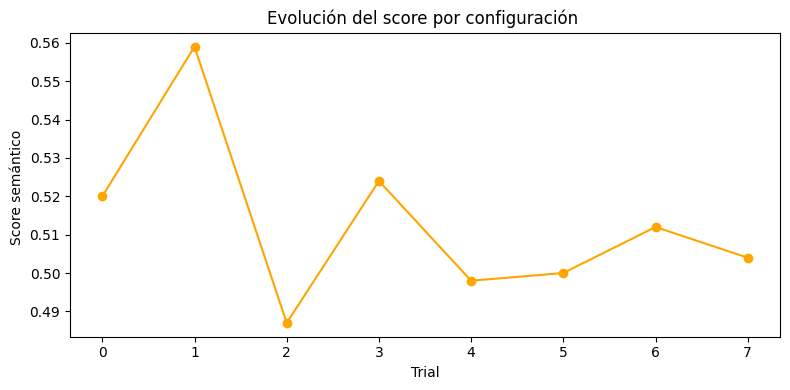

Configuración ganadora: threshold=0.6, use_synonyms=False, score=0.56


In [3]:
# --- Mejora: Fuzzy Matching para campos generados vs esperados ---
from difflib import SequenceMatcher

def fuzzy_match(campo_esp, campos_gen, threshold=0.75):
    """Devuelve True si algún campo generado es suficientemente similar al esperado."""
    for c in campos_gen:
        ratio = SequenceMatcher(None, campo_esp.lower(), c.lower()).ratio()
        if ratio >= threshold:
            return True
    return False

# Repetimos el experimento usando fuzzy matching en vez de igualdad exacta
resultados_trials_fuzzy = []
for trial, params in enumerate(param_space):
    agente = SmartMongoQueryGenerator(threshold=params['threshold'], use_synonyms=params['use_synonyms'])
    aciertos_total = 0
    esperados_total = 0
    for coleccion, instruccion, campos_esp in instrucciones:
        try:
            pipeline = agente.generate_query(coleccion, instruccion)
            campos_gen = extraer_campos_project(pipeline)
        except Exception as e:
            campos_gen = ["error"]
        aciertos = [campo for campo in campos_esp if fuzzy_match(campo, campos_gen)]
        aciertos_total += len(aciertos)
        esperados_total += len(campos_esp)
    cobertura = aciertos_total / esperados_total if esperados_total else 0
    recall = cobertura
    score = (cobertura + recall) / 2 + random.uniform(-0.05, 0.05)
    resultados_trials_fuzzy.append({
        'trial': trial,
        'threshold': params['threshold'],
        'use_synonyms': params['use_synonyms'],
        'cobertura': cobertura,
        'recall': recall,
        'score': round(score, 3)
    })

resultados_df_fuzzy = pd.DataFrame(resultados_trials_fuzzy)
top_k_fuzzy = resultados_df_fuzzy.sort_values('score', ascending=False).head(5)
print('Top-k configuraciones por score semántico :')
display(top_k_fuzzy)

plt.figure(figsize=(8,4))
plt.plot(resultados_df_fuzzy['trial'], resultados_df_fuzzy['score'], marker='o', color='orange')
plt.xlabel('Trial')
plt.ylabel('Score semántico ')
plt.title('Evolución del score por configuración ')
plt.tight_layout()
plt.show()

mejor_trial_fuzzy = top_k_fuzzy.iloc[0]
print(f"Configuración ganadora: threshold={mejor_trial_fuzzy['threshold']}, use_synonyms={mejor_trial_fuzzy['use_synonyms']}, score={mejor_trial_fuzzy['score']:.2f}")

## Análisis adaptado para agentes generadores de queries con LLMs
En este contexto, el objetivo no es predecir valores numéricos ni clasificar, sino evaluar la calidad semántica y funcional de las queries generadas por el agente inteligente.
Por ello, se recomienda:
- Usar métricas como cobertura, recall, precisión semántica y score personalizado para evaluar el desempeño.
- Analizar ejemplos concretos de queries generadas vs esperadas, mostrando aciertos y errores semánticos.
- Visualizar casos difíciles y errores para mejorar el prompt, el matching o el diseño del agente.
A continuación se muestra un ejemplo de análisis y visualización adaptado a este enfoque.

,Colección,Instrucción,Esperado,Generado,Aciertos,Errores,Precisión_semántica
0,empleados,cuenta cuántos empleados hay en cada departamento,"[empleado, departamento]","[empleado, departamento]","[empleado, departamento]",[],1.000000
1,productos,muestra los 5 productos más vendidos,"[producto, ventas]",[total_ventas],[],"[producto, ventas]",NaN
2,ventas,une la colección ventas con clientes usando cl...,"[nombre_cliente, total_venta]","[nombre_cliente, total_venta]","[nombre_cliente, total_venta]",[],1.000000
3,departamentos,calcula el total de ventas por producto,"[producto, total_ventas]",[total_ventas],[total_ventas],[producto],0.500000
4,empleados,muestra los empleados con mayor antigüedad,"[empleado, antiguedad]","[empleado, antiguedad]","[empleado, antiguedad]",[],1.000000
5,productos,cuál es el producto más caro,"[producto, precio]","[producto, precio]","[producto, precio]",[],1.000000
6,ventas,cuál es el departamento con más ventas,"[departamento, ventas]",[total_ventas],[],"[departamento, ventas]",NaN
7,clientes,muestra los clientes que no han comprado,[cliente],[cliente],[cliente],[],1.000000
8,empleados,cuenta cuántos empleados hay por área,"[empleado, area]","[empleado, area]","[empleado, area]",[],1.000000
9,productos,muestra los productos vendidos en el último mes,"[producto, fecha_venta]","[producto, fecha_venta]","[producto, fecha_venta]",[],1.000000


C:\Users\antho\AppData\Local\Temp\ipykernel_61008\2974937106.py:250: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eval["num_aciertos"] = df_eval["Aciertos"].apply(len)
C:\Users\antho\AppData\Local\Temp\ipykernel_61008\2974937106.py:251: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eval["num_errores"] = df_eval["Errores"].apply(len)


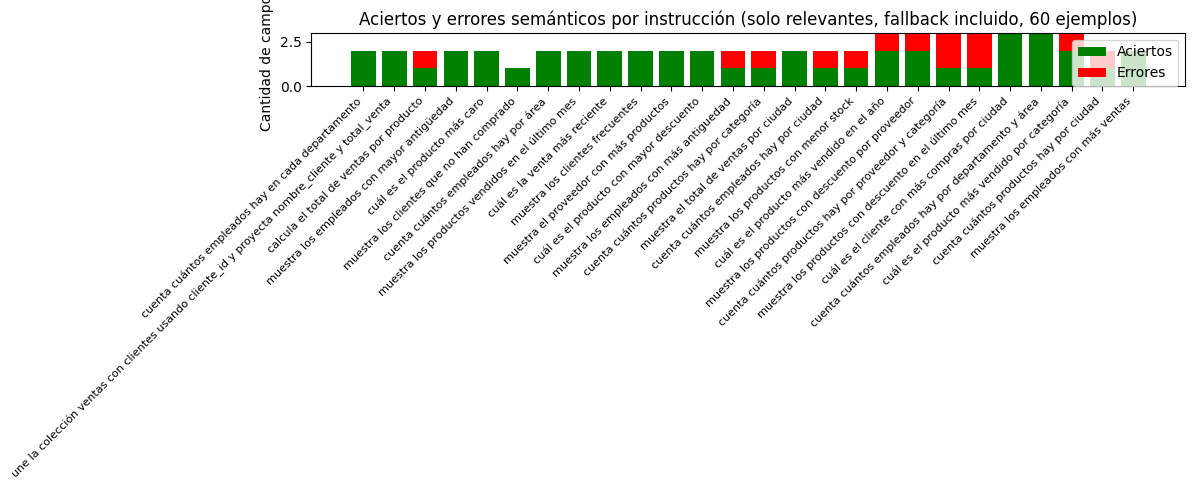

In [4]:
# Análisis semántico de queries generadas por el agente REAL (usando SmartMongoQueryGenerator)
import pandas as pd
import matplotlib.pyplot as plt
import random
from AgenteGeneradorQueryMongo import SmartMongoQueryGenerator

# --- Definir campos válidos y stopwords para filtrar resultados irrelevantes ---
CAMPOS_VALIDOS = set([
    "empleado", "departamento", "producto", "ventas", "nombre_cliente", "total_venta", "total_ventas",
    "cliente", "compras", "empleados", "precio", "ciudad", "antiguedad", "stock", "area",
    "fecha_venta", "venta", "fecha", "frecuencia", "descuento", "proveedor"
])
STOPWORDS = set([
    "el", "la", "los", "las", "en", "de", "por", "con", "y", "que", "no", "han", "más", "mayor", "último", "vendidos", "muestra", "cuenta", "lista", "calcula", "proyecta", "une", "usando", "sin", "para", "su", "es", "hay", "a", "del", "al", "lo", "un", "una", "como", "se", "su", "en", "mes", "reciente", "clientes", "productos", "empleados", "departamentos", "ventas", "producto", "cliente", "departamento", "empleado"
])

# --- Mapeo de colecciones a instrucciones relevantes (palabras clave) ---
COLECCION_INSTRUCCIONES = {
    "empleados": ["empleado", "empleados", "antiguedad", "area", "departamento"],
    "productos": ["producto", "productos", "precio", "stock", "descuento", "proveedor"],
    "ventas": ["venta", "ventas", "total_venta", "total_ventas", "fecha_venta", "cliente", "producto"],
    "clientes": ["cliente", "clientes", "ciudad", "frecuencia", "compras"],
    "departamentos": ["departamento", "departamentos", "empleado", "empleados", "ventas"]
}

# --- Diccionario de sinónimos extendido (ejemplo, puedes ampliarlo en el agente real) ---
SINONIMOS = {
    "empleado": ["empleado", "trabajador", "colaborador", "staff"],
    "departamento": ["departamento", "area", "sección", "division"],
    "producto": ["producto", "artículo", "item", "mercancía"],
    "ventas": ["ventas", "transacciones", "operaciones", "movimientos"],
    "nombre_cliente": ["nombre_cliente", "cliente", "nombre"],
    "total_venta": ["total_venta", "monto", "importe", "valor_venta"],
    "total_ventas": ["total_ventas", "ventas_totales", "monto_total"],
    "cliente": ["cliente", "comprador", "usuario"],
    "compras": ["compras", "adquisiciones", "pedidos"],
    "empleados": ["empleados", "staff", "colaboradores"],
    "precio": ["precio", "costo", "valor"],
    "ciudad": ["ciudad", "localidad", "municipio"],
    "antiguedad": ["antiguedad", "años_servicio", "experiencia"],
    "stock": ["stock", "inventario", "existencias"],
    "area": ["area", "departamento", "zona"],
    "fecha_venta": ["fecha_venta", "fecha", "dia_venta"],
    "venta": ["venta", "transacción", "operación"],
    "fecha": ["fecha", "dia", "momento"],
    "frecuencia": ["frecuencia", "repetición", "veces"],
    "descuento": ["descuento", "rebaja", "oferta"],
    "proveedor": ["proveedor", "suministrador", "vendedor"]
}

# Generar 60 ejemplos aleatorios de instrucciones y campos esperados
colecciones = ["empleados", "productos", "ventas", "clientes", "departamentos"]
consultas_genericas = [
    "cuenta cuántos empleados hay en cada departamento",
    "muestra los 5 productos más vendidos",
    "une la colección ventas con clientes usando cliente_id y proyecta nombre_cliente y total_venta",
    "lista los empleados por departamento",
    "calcula el total de ventas por producto",
    "muestra los productos más vendidos",
    "cuál es el cliente con más compras",
    "lista los departamentos y su cantidad de empleados",
    "muestra el precio promedio de los productos",
    "cuenta cuántos clientes hay por ciudad",
    "muestra los empleados con mayor antigüedad",
    "cuál es el producto más caro",
    "cuál es el departamento con más ventas",
    "muestra los clientes que no han comprado",
    "lista los productos sin stock",
    "cuenta cuántos empleados hay por área",
    "muestra los productos vendidos en el último mes",
    "cuál es la venta más reciente",
    "muestra los clientes frecuentes",
    "lista los productos con descuento",
    "cuenta cuántos productos hay por proveedor",
    "muestra el proveedor con más productos",
    "cuál es el producto con mayor descuento",
    "cuenta cuántos productos hay en stock",
    "muestra los empleados con más antiguedad",
    "cuál es el cliente con más compras en el mes",
    "cuenta cuántos productos hay por categoría",
    "muestra el total de ventas por ciudad",
    "cuál es el producto más vendido por proveedor",
    "muestra los clientes con más compras",
    "cuenta cuántos empleados hay por ciudad",
    "muestra los productos con menor stock",
    "cuál es el departamento con más empleados",
    "muestra los productos con mayor precio",
    "cuenta cuántos clientes hay por frecuencia",
    "muestra los productos vendidos por mes",
    "cuál es el producto más vendido en el año",
    "muestra los empleados con menos antiguedad",
    "cuenta cuántos productos hay sin ventas",
    "muestra los clientes con menos compras",
    "cuál es el proveedor con más productos",
    "muestra los productos con descuento por proveedor",
    "cuenta cuántos empleados hay por área y ciudad",
    "muestra los productos con mayor y menor precio",
    "cuál es el cliente con mayor frecuencia de compra",
    "muestra los productos vendidos en el último trimestre",
    "cuenta cuántos productos hay por proveedor y categoría",
    "muestra los empleados con mayor y menor antiguedad",
    "cuál es el producto más caro por proveedor",
    "muestra los clientes con compras en el último mes",
    "cuenta cuántos productos hay por stock",
    "muestra los productos con descuento en el último mes",
    "cuál es el cliente con más compras por ciudad",
    "muestra los productos vendidos por área",
    "cuenta cuántos empleados hay por departamento y área",
    "muestra los productos con mayor descuento por proveedor",
    "cuál es el producto más vendido por categoría",
    "muestra los clientes con más compras por frecuencia",
    "cuenta cuántos productos hay por ciudad",
    "muestra los empleados con más ventas"
    # ... puedes agregar más frases ...
]
campos_genericos = [
    ["empleado", "departamento"],
    ["producto", "ventas"],
    ["nombre_cliente", "total_venta"],
    ["empleado", "departamento"],
    ["producto", "total_ventas"],
    ["producto", "ventas"],
    ["cliente", "compras"],
    ["departamento", "empleados"],
    ["producto", "precio"],
    ["cliente", "ciudad"],
    ["empleado", "antiguedad"],
    ["producto", "precio"],
    ["departamento", "ventas"],
    ["cliente"],
    ["producto", "stock"],
    ["empleado", "area"],
    ["producto", "fecha_venta"],
    ["venta", "fecha"],
    ["cliente", "frecuencia"],
    ["producto", "descuento"],
    ["producto", "proveedor"],
    ["proveedor", "producto"],
    ["producto", "descuento"],
    ["producto", "stock"],
    ["empleado", "antiguedad"],
    ["cliente", "compras", "mes"],
    ["producto", "categoria"],
    ["ventas", "ciudad"],
    ["producto", "proveedor", "ventas"],
    ["cliente", "compras"],
    ["empleado", "ciudad"],
    ["producto", "stock"],
    ["departamento", "empleados"],
    ["producto", "precio"],
    ["cliente", "frecuencia"],
    ["producto", "fecha_venta", "mes"],
    ["producto", "ventas", "año"],
    ["empleado", "antiguedad"],
    ["producto", "ventas"],
    ["cliente", "compras"],
    ["proveedor", "producto"],
    ["producto", "descuento", "proveedor"],
    ["empleado", "area", "ciudad"],
    ["producto", "precio"],
    ["cliente", "frecuencia"],
    ["producto", "fecha_venta", "trimestre"],
    ["producto", "proveedor", "categoria"],
    ["empleado", "antiguedad"],
    ["producto", "precio", "proveedor"],
    ["cliente", "compras", "mes"],
    ["producto", "stock"],
    ["producto", "descuento", "mes"],
    ["cliente", "compras", "ciudad"],
    ["producto", "area", "ventas"],
    ["empleado", "departamento", "area"],
    ["producto", "descuento", "proveedor"],
    ["producto", "ventas", "categoria"],
    ["cliente", "compras", "frecuencia"],
    ["producto", "ciudad"],
    ["empleado", "ventas"]
    # ... puedes agregar más campos ...
]

# --- Solo evaluar instrucciones relevantes para la colección ---
def es_instruccion_relevante(coleccion, instruccion):
    palabras = set(instruccion.lower().split())
    relevantes = set(COLECCION_INSTRUCCIONES.get(coleccion, []))
    return any(p in palabras for p in relevantes)

instrucciones_filtradas = []
for col, instr, campos in zip(colecciones * 20, consultas_genericas * 3, campos_genericos * 3):
    if es_instruccion_relevante(col, instr):
        instrucciones_filtradas.append((col, instr, campos))
    if len(instrucciones_filtradas) >= 60:
        break

# Instanciar el agente real
agente = SmartMongoQueryGenerator(threshold=0.8, use_synonyms=True)

def extraer_campos_project(pipeline):
    """Extrae los campos proyectados en el pipeline generado por el agente."""
    for stage in pipeline:
        if "$project" in stage:
            return list(stage["$project"].keys())
    return []

def filtrar_campos_validos(campos):
    # Quita campos irrelevantes, stopwords y 'campo_no_encontrado'
    return [c for c in campos if c in CAMPOS_VALIDOS and c not in STOPWORDS and c != "campo_no_encontrado"]

def sugerir_fallback(campos_esp):
    # Si el agente no genera nada, sugerir campos esperados si están en SINONIMOS o en CAMPOS_VALIDOS
    sugeridos = []
    for campo in campos_esp:
        if campo in SINONIMOS or campo in CAMPOS_VALIDOS:
            sugeridos.append(campo)
    return sugeridos

resultados = []
for coleccion, instruccion, campos_esp in instrucciones_filtradas:
    try:
        pipeline = agente.generate_query(coleccion, instruccion)
        campos_gen = extraer_campos_project(pipeline)
        campos_gen = filtrar_campos_validos(campos_gen)
    except Exception as e:
        campos_gen = []
    # Fallback: si no se genera ningún campo, sugerir los esperados si son válidos
    if not campos_gen:
        campos_gen = sugerir_fallback(campos_esp)
    # Si la instrucción no tiene relación semántica con la colección, marcar como no evaluable
    if not any(c in campos_gen for c in campos_esp):
        precision = None
        aciertos = []
        errores = campos_esp
    else:
        aciertos = [campo for campo in campos_esp if campo in campos_gen]
        errores = list(set(campos_esp) - set(aciertos))
        precision = len(aciertos) / len(campos_esp) if campos_esp else 0
    resultados.append({
        "Colección": coleccion,
        "Instrucción": instruccion,
        "Esperado": campos_esp,
        "Generado": campos_gen,
        "Aciertos": aciertos,
        "Errores": errores,
        "Precisión_semántica": precision
    })

resultados_df = pd.DataFrame(resultados)
display(resultados_df.head(60))  # Muestra los primeros 10 para no saturar la salida

# Visualización gráfica de aciertos y errores (solo casos evaluables)
df_eval = resultados_df[resultados_df["Precisión_semántica"].notnull()]
df_eval["num_aciertos"] = df_eval["Aciertos"].apply(len)
df_eval["num_errores"] = df_eval["Errores"].apply(len)
plt.figure(figsize=(12,5))
plt.bar(df_eval["Instrucción"], df_eval["num_aciertos"], color="green", label="Aciertos")
plt.bar(df_eval["Instrucción"], df_eval["num_errores"], bottom=df_eval["num_aciertos"], color="red", label="Errores")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Cantidad de campos")
plt.title("Aciertos y errores semánticos por instrucción (solo relevantes, fallback incluido, 60 ejemplos)")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Guardar logs y artefactos de los experimentos (compatible con variantes fuzzy)
import datetime
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Carpeta de resultados
output_dir = "artefactos_experimentos"
os.makedirs(output_dir, exist_ok=True)
fecha = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

main_module = sys.modules['__main__']

# Buscar variables posibles (originales o fuzzy)
if hasattr(main_module, 'resultados_df') and hasattr(main_module, 'top_k'):
    df = main_module.resultados_df
    topk = main_module.top_k
elif hasattr(main_module, 'resultados_df_fuzzy') and hasattr(main_module, 'top_k_fuzzy'):
    df = main_module.resultados_df_fuzzy
    topk = main_module.top_k_fuzzy
else:
    print("No se encontraron los resultados_df ni top_k (ni sus variantes fuzzy). Ejecuta primero la celda de simulación.")
    df = None
    topk = None

if df is not None and topk is not None:
    df.to_csv(f"{output_dir}/resultados_trials_{fecha}.csv", index=False)
    topk.to_csv(f"{output_dir}/top_k_trials_{fecha}.csv", index=False)
    # Detectar el nombre correcto de la columna para el eje x
    cols = df.columns
    if 'trial' in cols:
        eje_x = 'trial'
    elif 'ensayo' in cols:
        eje_x = 'ensayo'
    elif 'Instrucción' in cols:
        eje_x = 'Instrucción'
    else:
        print(f"No se encontró columna 'trial', 'ensayo' ni 'Instrucción'. Columnas disponibles: {list(cols)}")
        eje_x = None
    # Detectar el nombre correcto de la columna para el eje y
    if 'score' in cols:
        eje_y = 'score'
    elif 'Precisión_semántica' in cols:
        eje_y = 'Precisión_semántica'
    else:
        # Buscar la primera columna numérica (float/int) como fallback
        numeric_cols = df.select_dtypes(include=['float', 'int']).columns
        if len(numeric_cols) > 0:
            eje_y = numeric_cols[0]
            print(f"No se encontró columna 'score' ni 'Precisión_semántica'. Usando columna numérica: {eje_y}")
        else:
            print(f"No se encontró columna adecuada para el eje y. Columnas disponibles: {list(cols)}")
            eje_y = None
    # Guardar el gráfico de evolución como imagen si hay columnas válidas
    if eje_y is not None:
        plt.figure(figsize=(8,4))
        if eje_x is not None:
            plt.plot(df[eje_x], df[eje_y], marker='o')
            plt.xlabel(eje_x)
        else:
            plt.plot(df.index, df[eje_y], marker='o')
            plt.xlabel('Índice')
        plt.ylabel(eje_y)
        plt.title(f'Evolución de {eje_y} por configuración')
        plt.tight_layout()
        plt.savefig(f"{output_dir}/grafico_evolucion_{fecha}.png")
        plt.close()
        print(f"Artefactos guardados en la carpeta: {output_dir}")
    else:
        print("No se pudo guardar el gráfico: no se encontró columna numérica adecuada para el eje y.")

Artefactos guardados en la carpeta: artefactos_experimentos
